# ISYE 6420 Homework 4

In [1]:
import numpy as np
from scipy.stats import gamma, beta, binom
import matplotlib.pyplot as plt
from scipy.optimize import fsolve   

from tqdm import tqdm
import arviz

## Question 1

### Setting up equations for likelihood

In [2]:
def L(x,theta, mu):
    """
    Likelihood function for Normal distribution where theta is precision parameter (1/variance).
    """
    return np.sqrt(theta / (2 * np.pi)) * np.exp(-0.5 * theta * (x - mu) ** 2)

### Run Metropolis-Hastings Algorithm

In [3]:
obs = 10500
burn = 500
theta = 0.5
rng = np.random.default_rng(seed=6420)

def metropolis_hastings(theta, a, b, obs):
    # observed data
    x = -2
    # hyperparameters
    mu = 0
    prior_a = 1/2
    prior_b = 1
    accepted = np.zeros(obs)
    # create samples array
    theta_samples = np.zeros(obs)
    unif = rng.uniform(size=obs)
    

    for i in tqdm(range(obs)):
        # sample from proposal distribution by inverse transform sampling
        theta_proposal = gamma.ppf(rng.uniform(), a=a, scale=1/b)

        # calculate acceptance ratio
        likelihood_current = L(x, theta, mu)
        likelihood_new = L(x, theta_proposal, mu)

        prior_current = gamma.pdf(theta, a=prior_a, scale=1/prior_b)
        prior_new = gamma.pdf(theta_proposal, a=prior_a, scale=1/prior_b)

        proposal_current = gamma.pdf(theta, a=a, scale=1/b)
        proposal_new = gamma.pdf(theta_proposal, a=a, scale=1/b)

        acceptance_ratio = (likelihood_new * prior_new * proposal_current) / (likelihood_current * prior_current * proposal_new)
        acceptance_ratio = min(1, acceptance_ratio)
        # accept or reject
        if unif[i] < acceptance_ratio:
            theta = theta_proposal
            accepted[i] = 1
        theta_samples[i] = theta

    return theta_samples, accepted

# Selected for efficacy, these are the parameters for the proposal distribution
a = 1
b = 4

theta_samples, accepted = metropolis_hastings(theta, a, b, obs)

100%|██████████| 10500/10500 [00:09<00:00, 1112.35it/s]


### Trace Plot

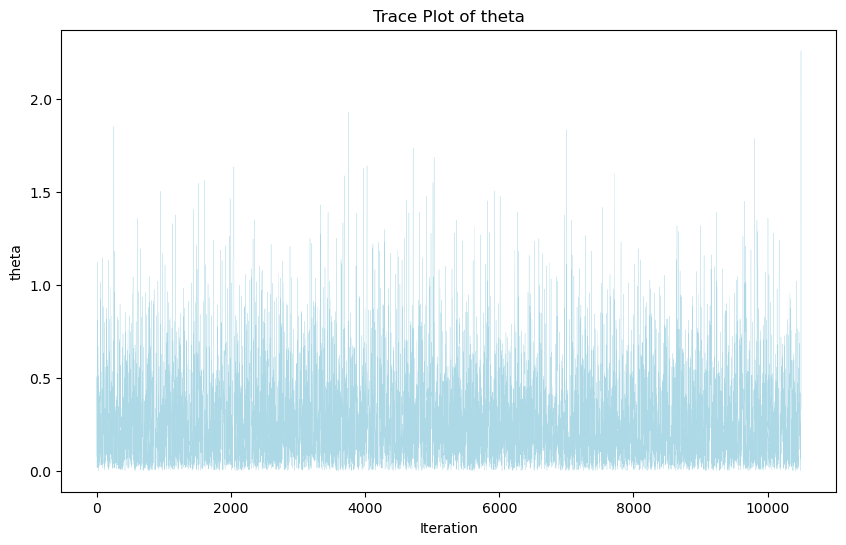

In [4]:
# plot trace plot
plt.figure(figsize=(10, 6))
plt.plot(range(obs), theta_samples, color='lightblue', linewidth=0.2)
plt.title('Trace Plot of theta')
plt.xlabel('Iteration')
plt.ylabel('theta')
plt.show()

### Discard the first 500 samples

Acceptance Rate: 0.858
Mean of theta samples (after burn-in): 0.3283
Variance of theta samples (after burn-in): 0.0988


Text(0.5, 1.0, 'Posterior Distribution of theta (after burn-in)')

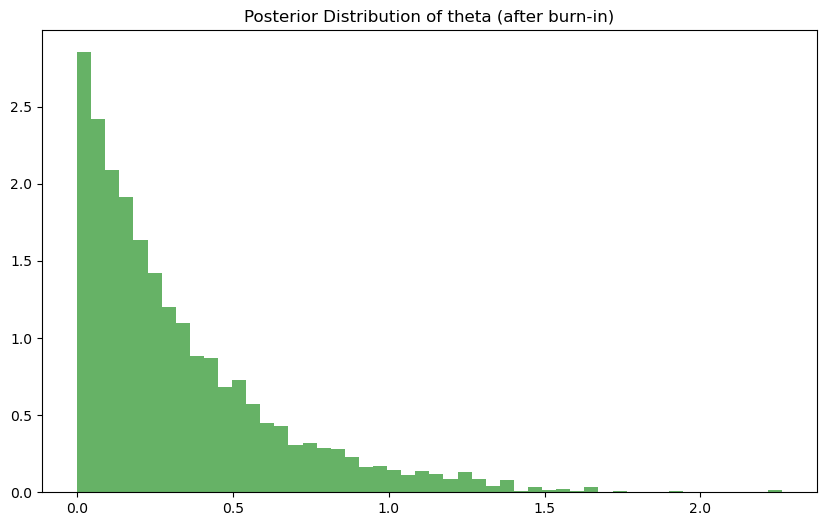

In [5]:
burn = 500
theta_samples_burned = theta_samples[burn:]
print(f"Acceptance Rate: {accepted.sum()/obs:.3f}")
print(f"Mean of theta samples (after burn-in): {theta_samples_burned.mean():.4f}")
print(f"Variance of theta samples (after burn-in): {theta_samples_burned.var():.4f}")

# Posterior densities plotted
plt.figure(figsize=(10, 6))
plt.hist(theta_samples_burned, bins=50, density=True, alpha=0.6, color='g')
plt.title('Posterior Distribution of theta (after burn-in)')


### Posterior Distribution
The posterior distribution is a gamma function with a=1, which is equivalent to an exponential distribution.

In the case the proposed posterior distribution is not an exact solution, we can calculate the Bayes estimator by taking the mean of the theta samples.

In [6]:
print(f"Bayes Estimator (posterior mean) of theta (after burn-in): {theta_samples_burned.mean():.4f}")

Bayes Estimator (posterior mean) of theta (after burn-in): 0.3283


### 97% HPD Credible Set

In [7]:
hdi_array = arviz.hdi(theta_samples_burned, hdi_prob=0.97)
# round the HDI values for better readability
hdi_array_rounded = np.round(hdi_array, 2)
print(f"HDI Credible Interval (using ArviZ): [{hdi_array_rounded[0]:.2f}, {hdi_array_rounded[1]:.2f}]")


HDI Credible Interval (using ArviZ): [0.00, 1.14]


### Overlay exact distribution with existing proposal distribution

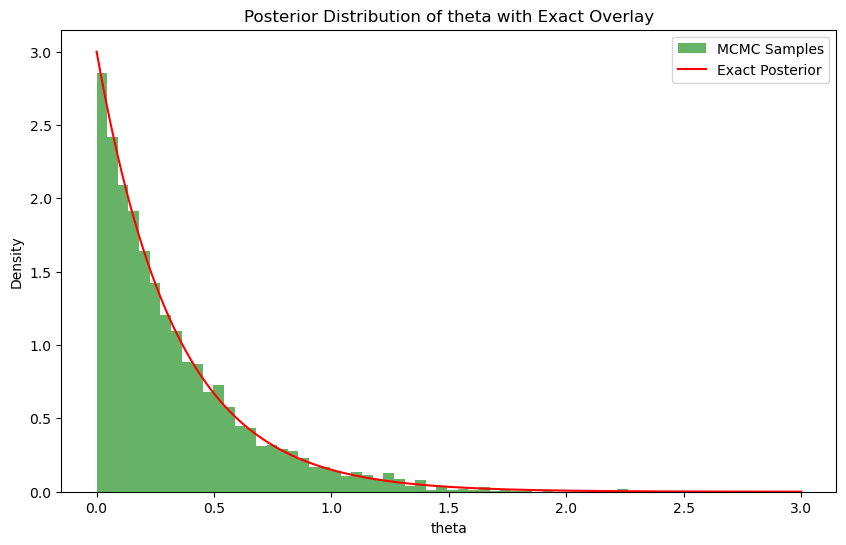

In [8]:
x = np.linspace(0, 3, 500)
plt.figure(figsize=(10, 6))
plt.hist(theta_samples_burned, bins=50, density=True, alpha=0.6, color='g', label='MCMC Samples')
plt.plot(x, gamma.pdf(x, a=1, scale=1/3), 'r-', label='Exact Posterior')
plt.title('Posterior Distribution of theta with Exact Overlay')
plt.xlabel('theta')
plt.ylabel('Density')
plt.legend()
plt.show()

### Exact Posterior Distribution
Found using the Normal-Gamma conjugacy for the precision parameter. Rerunning metropolis algorithm with the known exact parameters.

100%|██████████| 10500/10500 [00:09<00:00, 1120.46it/s]


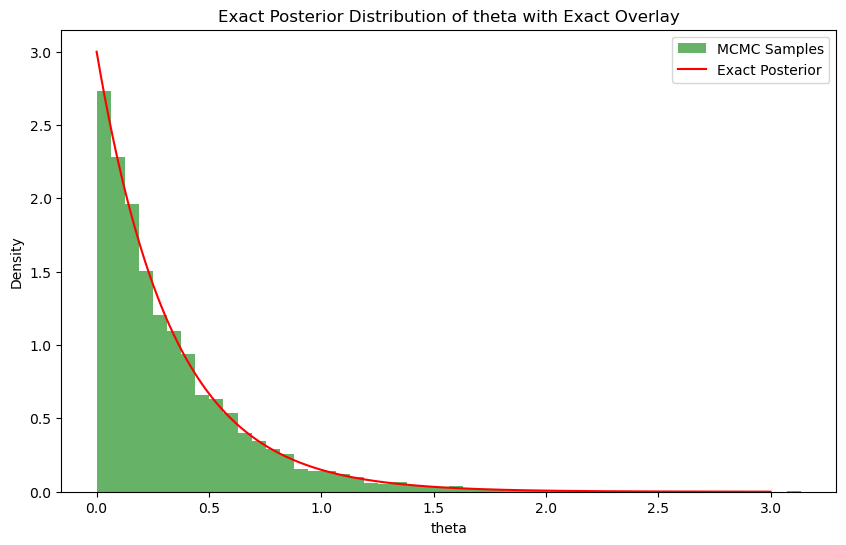

Acceptance Rate: 1.000
Bayes Estimator (posterior mean) of theta (after burn-in): 0.3325
HDI Credible Interval (using ArviZ) for exact posterior: (0.0, 1.17)


In [9]:
exact_a = 1
exact_b = 3
theta = 0.5
exact_theta_samples, exact_accepted = metropolis_hastings(theta, exact_a, exact_b, obs)
burn = 500
exact_theta_samples_burned = exact_theta_samples[burn:]
# Overlay MCMC samples with exact posterior distribution'
x = np.linspace(0, 3, 500)
plt.figure(figsize=(10, 6))
plt.hist(exact_theta_samples_burned, bins=50, density=True, alpha=0.6, color='g', label='MCMC Samples')
plt.plot(x, gamma.pdf(x, a=exact_a, scale=1/exact_b), 'r-', label='Exact Posterior')
plt.title('Exact Posterior Distribution of theta with Exact Overlay')
plt.xlabel('theta')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"Acceptance Rate: {exact_accepted.sum()/obs:.3f}")
print(f"Bayes Estimator (posterior mean) of theta (after burn-in): {exact_theta_samples_burned.mean():.4f}")
credible_set_exact = np.round(arviz.hdi(exact_theta_samples_burned, hdi_prob=0.97)[0], 2), np.round(arviz.hdi(exact_theta_samples_burned, hdi_prob=0.97)[1], 2)
print(
    f"HDI Credible Interval (using ArviZ) for exact posterior: {credible_set_exact}"
    )

## Question 2

### Conditional Distributions

#### $y_0$ Conditional
Setting $\phi = \frac{\frac{1}{2}}{\frac{1}{2} + \frac{\theta}{4}}$
$$
\pi(y_0|\theta, y_1) = \binom{y_1}{y_0} \phi^{y_0}(1-\phi)^{y_1-y_0}
$$
$$
\pi(y_0|\theta, y_1) \sim Bin(y_1,\phi)
$$

#### $\theta$ Conditional
$$
\pi(\theta|y_0, \bar{y}) \sim Beta((y_1-y_0+y_4+1),(y_2+y_3+1))
$$
where $\alpha=(y_1-y_0+y_4+1),\beta=(y_2+y_3+1)$.

In [10]:
# Gibbs Sampling
obs = 10000
rng = np.random.default_rng(seed=6420)
# observed data
y1 = 125
y2 = 18
y3 = 20
y4 = 34

# hyperparameters
n = 197

# inits
theta = 0

thetas = np.zeros(obs)

for i in tqdm(range(obs)):
    # Create variable phi from theta
    phi = (1/2) / (1/2 + (theta/4))
    # Sample y0 from Binomial distribution
    y0 = rng.binomial(n=y1, p=phi)

    # Sample theta from Beta distribution
    theta = rng.beta(a=y1-y0+y4+1, b=y2+y3+1)
    thetas[i] = theta

100%|██████████| 10000/10000 [00:00<00:00, 209111.91it/s]


Bayes Estimator (posterior mean) of theta: 0.622
Variance of theta samples: 0.003


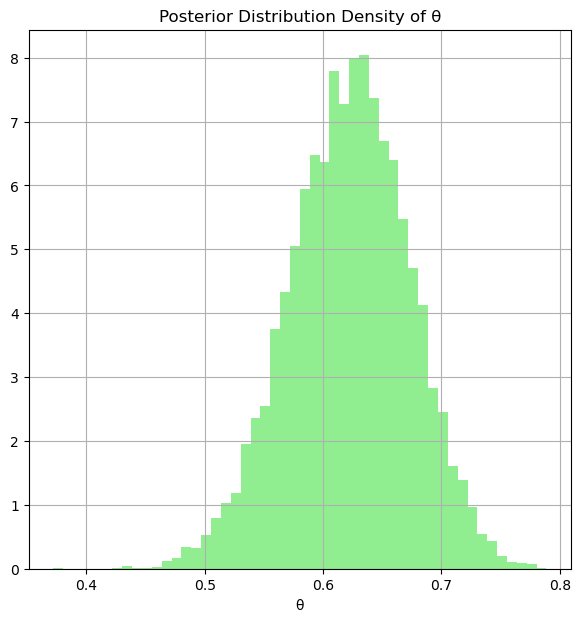

In [11]:
print(f"Bayes Estimator (posterior mean) of theta: {thetas.mean():.3f}")
print(f"Variance of theta samples: {thetas.var():.3f}")

# posterior densities
fig, ax = plt.subplots(figsize=(7, 7))

ax.grid(True)
ax.hist(thetas, color="lightgreen", density=True, bins=50)
ax.set_xlabel("θ")
ax.set_title("Posterior Distribution Density of θ")
plt.show()

In [12]:
# Find 95% equi-tailed credible interval
lower = np.percentile(thetas, 2.5)
upper = np.percentile(thetas, 97.5)
print(f"95% Equi-tailed Credible Interval: [{lower:.2f}, {upper:.2f}]")
print(
    "Probability within set: ", round(np.mean((thetas >= lower) & (thetas <= upper)), 3)
    )

95% Equi-tailed Credible Interval: [0.52, 0.72]
Probability within set:  0.95


## Question 3

In [13]:
def bickel_levit(theta, m=2):
    """
    Bickel-Levit prior distribution
    """
    return (1/m) * (np.cos((np.pi * theta) / (2*m))) ** 2


def normal_likelihood(y, theta, tau):
    """
    Likelihood function for Normal distribution where tau is precision parameter (1/variance).
    """
    individual_likelihoods = np.sqrt(tau / (2 * np.pi)) * np.exp(-0.5 * tau * (y - theta) ** 2)
    return np.prod(individual_likelihoods)

Proposal distribution is assumed to be a uniform distribution between -2 and 2. Considering we want a stationary distribution with specific bounds, a uniform distribution is the simplest to implement, although a truncated normal distribution could also offer as an interesting proposal distribution given it meets our criteria.

In [14]:
def metropolis_hastings_2(theta, obs, lower=-2, upper=2):
    # observed data
    y = np.array([-2, -1, 5, -7, 0, 4, 2])
    # hyperparameters
    m = 2
    tau=1/2

    accepted = np.zeros(obs)
    # create samples array
    theta_samples = np.zeros(obs)
    unif_proposal = rng.uniform(size=obs)
    unif_accept = rng.uniform(size=obs)
    
    for i in tqdm(range(obs)):
        # sample from proposal distribution by inverse transform sampling
        theta_proposal = lower + (upper - lower) * unif_proposal[i]  # Uniform distribution between lower and upper

        # calculate acceptance ratio
        likelihood_current = normal_likelihood(y, theta, tau)
        likelihood_new = normal_likelihood(y, theta_proposal, tau)

        prior_current = bickel_levit(theta, m)
        prior_new = bickel_levit(theta_proposal, m)

        acceptance_ratio = (likelihood_new * prior_new) / (likelihood_current * prior_current)
        acceptance_ratio = min(1, acceptance_ratio)
        #acceptance_ratio = min(1, acceptance_ratio)
        # accept or reject
        if unif_accept[i] < acceptance_ratio:
            theta = theta_proposal
            accepted[i] = 1
        theta_samples[i] = theta

    return theta_samples, accepted

obs=10500
rng = np.random.default_rng(seed=6420)
theta_samples_3, accepted_3 = metropolis_hastings_2(theta, obs)

100%|██████████| 10500/10500 [00:00<00:00, 24457.72it/s]


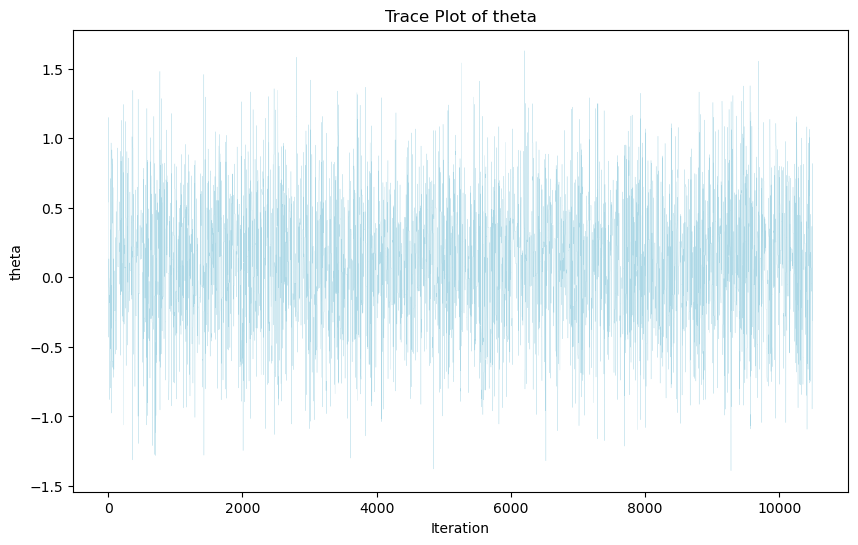

In [15]:
# plot trace plot
plt.figure(figsize=(10, 6))
plt.plot(range(obs), theta_samples_3, color='lightblue', linewidth=0.2)
plt.title('Trace Plot of theta')
plt.xlabel('Iteration')
plt.ylabel('theta')
plt.show()

### Discard the first 500 samples

Acceptance Rate: 0.361
Mean of theta samples (after burn-in): 0.1084
Variance of theta samples (after burn-in): 0.2015


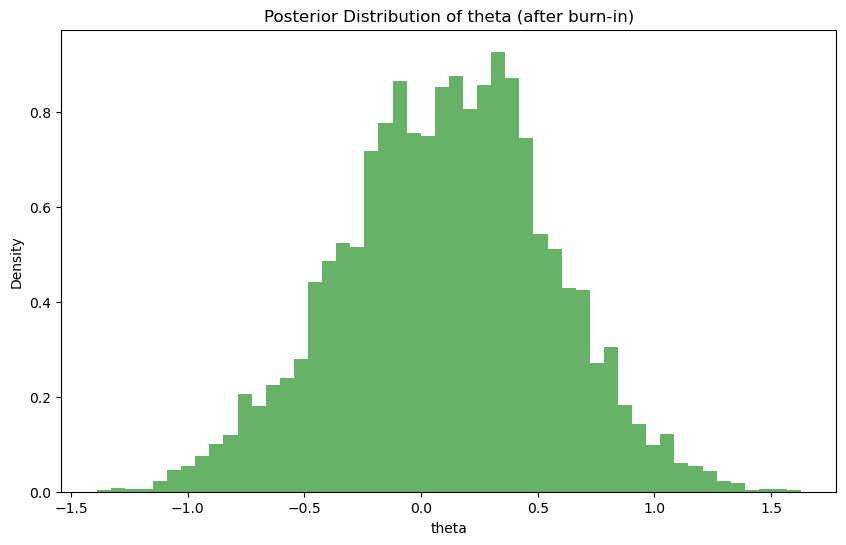

In [16]:
burn = 500
theta_samples_burned_3 = theta_samples_3[burn:]
print(f"Acceptance Rate: {accepted_3.sum()/obs:.3f}")
print(f"Mean of theta samples (after burn-in): {theta_samples_burned_3.mean():.4f}")
print(f"Variance of theta samples (after burn-in): {theta_samples_burned_3.var():.4f}")

# Posterior densities plotted
plt.figure(figsize=(10, 6))
plt.hist(theta_samples_burned_3, bins=50, density=True, alpha=0.6, color='g')
plt.title('Posterior Distribution of theta (after burn-in)')
plt.xlabel('theta')
plt.ylabel('Density')
plt.show()


#### Bayes estimator (posterior mean)

In [17]:
print(f"Bayes estimator (posterior mean) of theta (after burn-in): {theta_samples_burned_3.mean():.3f}")

Bayes estimator (posterior mean) of theta (after burn-in): 0.108


#### 95% equi-tailed credible set

In [18]:
# Get 95% equi-tailed credible interval
lower = np.percentile(theta_samples_burned_3, 2.5)
upper = np.percentile(theta_samples_burned_3, 97.5)
print(f"95% Equi-tailed Credible Interval: [{lower:.2f}, {upper:.2f}]")
print(
    "Probability within set: ", round(np.mean((theta_samples_burned_3 >= lower) & (theta_samples_burned_3 <= upper)), 3)
    )


95% Equi-tailed Credible Interval: [-0.80, 0.97]
Probability within set:  0.95
